# MLR Potential with Adiabatic BOB Correction

The ground–state N₂ PEC follows the $\textrm{MLR}_4(6,8)$ form of Le Roy (2006), using the  
same notation and parameters as Duo.

**Surkus variable**
$y_p(r; r_0) = \dfrac{r^p - r_0^p}{\,r^p + r_0^p\,}$

**Long–range potential**
$u_{\rm LR}(r) = \dfrac{C_6}{r^6} + \dfrac{C_8}{r^8}$

**Exponent coefficient**
$$
\beta_{\rm MLR}(r) =
y_p^{\rm ref}(r)\,\beta_\infty +
\bigl[1 - y_p^{\rm ref}(r)\bigr]
\sum_{i=0}^{N(r)} b_i \,[y_p^{\rm ref}(r)]^i
$$

with  
$N(r)=N_S$ for $r \le r_{\rm ref}$,  
$N(r)=N_L$ for $r>r_{\rm ref}$,  
and  
$\beta_\infty = \ln\!\left[\dfrac{2D_e}{u_{\rm LR}(r_e)}\right]$.

**MLR potential**
$$
V_{\rm MLR}(r) =
D_e \left[
1 - \dfrac{u_{\rm LR}(r)}{u_{\rm LR}(r_e)}
\exp\!\left(-\beta_{\rm MLR}(r)\,y_p^{\rm eq}(r)\right)
\right]^2
$$

**Adiabatic BOB correction (N nucleus)**
For N₂ only one term is non-zero:
$$
S_{\rm ad}(r) =
u_1^{\rm N}\, y_6(r)\,[1 - y_6(r)]
$$

**Total PEC (isotopologue $\xi$)**  
$$
V_{\rm cor}^{(\xi)}(r)
=
V_{\rm MLR}(r)
+ \Delta V_{\text{ad}}^{(\xi)}(r)=
V_{\rm MLR}(r)
+
\left[
\frac{M_{N_a}^{(\xi)} - M_{N_a}^{(1)}}{M_{N_a}^{(\xi)}}
+
\frac{M_{N_b}^{(\xi)} - M_{N_b}^{(1)}}{M_{N_b}^{(\xi)}}
\right]
S_{\rm ad}(r)
$$



In [1]:
import numpy as np
import matplotlib.pyplot as plt



# ==========================
# PARAMETERS FROM DUO BLOCK
# ==========================
Te   = 0.0
Re   = 0.10976790E+01       # Å
De   = 0.79845000000000E+05 # AE in cm-1 (De = AE - Te)
Rref = Re                   # here RREF == RE

P    = 4.0                  # p in MLR4
NS   = 6                    # inner exponent order
NL   = 8                    # outer exponent order

# exponent polynomial coefficients b_i (Le Roy's φ_i)
b = np.array([
    -0.234414547E+01,
    -0.972469000E+00,
    -0.156177700E+01,
    -0.113600000E+01,
    -0.139630000E+01,
    -0.819000000E+00,
    -0.450000000E+00,
    -0.336000000E+01,
     0.210000000E+01
])

# long-range coefficients
C6 = 0.11600000000000E+06   # cm-1 Å^6
C8 = 0.63800000000000E+06   # cm-1 Å^8

# ==========================
# BOB PARAMETER (adiabatic)
# ==========================
u1N = -14.1  # cm-1

# ==========================
# MASS PARAMETERS
# ==========================

# (update to correct values below - from Duo)
M_REF_A = M_REF_B = M_REF = M_14 = 14.003074004430 # nuclear mass of 14N in amu
M_15 = 15.000108898880 # nuclear mass of 15N in amu

# change below based on isotopologue being considered
M_A = M_14
M_B = M_15

MASS_FACTOR = ((M_A - M_REF_A) / M_A) + ((M_B - M_REF_B) / M_B)

# ==========================
# SUPPORT FUNCTIONS
# ==========================

def y_surkus(r, p, r0):
    r = np.asarray(r, dtype=float)
    rp  = r**p
    r0p = r0**p
    return (rp - r0p) / (rp + r0p)

def uLR(r):
    r = np.asarray(r, dtype=float)
    return C6 / r**6 + C8 / r**8

# β_MLR(r) with inner (NS) / outer (NL) orders, q = p
def beta_MLR(r):
    r  = np.asarray(r, dtype=float)
    yp = y_surkus(r, P, Rref)   # y_p^ref(r)
    yq = yp                     # q = p

    # start with inner polynomial (0..NS) everywhere
    poly = np.zeros_like(r, dtype=float)
    for i in range(NS + 1):
        poly += b[i] * yq**i

    # for r > Rref, add outer extra terms (NS+1..NL)
    if NL > NS:
        mask = r > Rref
        for i in range(NS + 1, NL + 1):
            poly[mask] += b[i] * yq[mask]**i

    beta_inf = np.log(2.0 * De / uLR(Re))  # β∞ = ln[2De / uLR(re)]
    return yp * beta_inf + (1.0 - yp) * poly

def V_MLR(r):
    """MLR potential (without BOB), Te = 0."""
    r    = np.asarray(r, dtype=float)
    yp_eq = y_surkus(r, P, Re)  # y_p^eq(r) in the exponent
    return De * (1.0 - (uLR(r) / uLR(Re)) * np.exp(-beta_MLR(r) * yp_eq))**2

# adiabatic BOB correction: S̃_ad(r) = u1N * y6 * (1 - y6)
def Delta_V(r):
    r  = np.asarray(r, dtype=float)
    y6 = y_surkus(r, 6, Re)
    S_r = u1N * y6 * (1.0 - y6)
    return MASS_FACTOR * S_r

def V_full(r):
    """MLR + adiabatic BOB correction."""
    r = np.asarray(r, dtype=float)
    return V_MLR(r) + Delta_V(r)


In [2]:
def load_duo_potential(filename):
    data = np.loadtxt(filename)
    r = data[:,0]
    V = data[:,1]
    return r, V


def compare_with_duo_data(r_duo, V_duo):
    """
    Compute MLR and MLR+BOB PEC values directly on Duo's grid.
    No plotting. Returns all arrays needed for external plotting.
    """
    V_mlr_duo  = V_MLR(r_duo)
    V_corr_duo = V_full(r_duo)

    res_mlr = V_mlr_duo - V_duo
    res_corr = V_corr_duo - V_duo
    
    return {
        "r": r_duo,
        "V_duo": V_duo,
        "V_mlr": V_mlr_duo,
        "V_corr": V_corr_duo,
        "res_mlr": res_mlr,
        "res_corr": res_corr
    }


In [3]:
def plot_compare_with_duo(data, rmin=None, rmax=None, show=True, return_fig=False):
    """
    Plot Duo PEC vs calculated PECs, with optional x-zoom.
    When rmin/rmax are specified, both subplots automatically rescale their
    y-limits to the visible region only.
    """
    r       = data["r"]
    V_duo   = data["V_duo"]
    V_mlr   = data["V_mlr"]
    V_corr  = data["V_corr"]
    res_mlr = data["res_mlr"]
    res_corr= data["res_corr"]

    fig, ax = plt.subplots(1, 2, figsize=(14,5))

    # ------------------------
    # PLOTTING
    # ------------------------
    # PECs
    ax[0].plot(r, V_duo,  label="Duo PEC",       lw=2)
    ax[0].plot(r, V_corr, '--', lw=1.8, label="MLR + BOB")
    ax[0].plot(r, V_mlr,  ':', lw=1.4, label="MLR only")

    ax[0].set_title("PEC Comparison")
    ax[0].set_xlabel("r (Å)")
    ax[0].set_ylabel("V(r) [cm⁻¹]")
    ax[0].grid(True)
    ax[0].legend()

    # Residuals
    ax[1].plot(r, res_mlr,  label="Residuals (MLR)",     lw=2)
    ax[1].plot(r, res_corr, label="Residuals (MLR+BOB)", lw=2)

    ax[1].set_title("Residuals (Calc - Duo)")
    ax[1].set_xlabel("r (Å)")
    ax[1].set_ylabel("Residual [cm⁻¹]")
    ax[1].grid(True)
    ax[1].legend()

    # ------------------------
    # AXIS SELECTION
    # ------------------------
    if rmin is not None or rmax is not None:
        
        # Apply x-limits
        ax[0].set_xlim(rmin, rmax)
        ax[1].set_xlim(rmin, rmax)

        # Mask data inside visible region
        mask = np.ones_like(r, dtype=bool)
        if rmin is not None:
            mask &= (r >= rmin)
        if rmax is not None:
            mask &= (r <= rmax)

        # PEC y-scaling
        ymin_pec = min(V_duo[mask].min(), V_mlr[mask].min(), V_corr[mask].min())
        ymax_pec = max(V_duo[mask].max(), V_mlr[mask].max(), V_corr[mask].max())
        ax[0].set_ylim(ymin_pec, ymax_pec)

        # Residual y-scaling
        ymin_res = min(res_mlr[mask].min(), res_corr[mask].min())
        ymax_res = max(res_mlr[mask].max(), res_corr[mask].max())
        ax[1].set_ylim(ymin_res, ymax_res)

    # ------------------------
    if show:
        plt.tight_layout()
        plt.show()

    if return_fig:
        return fig, ax


In [4]:
# r_duo, V_duo = load_duo_potential("uncorrected_PEC_14N2_1001pt.txt")
r_duo, V_duo = load_duo_potential("BOB_correction_data/uncorrected_PEC_1001pt.txt")

rgrid = np.linspace(0.20, 17, 10001)
V_mlr  = V_MLR(rgrid)
V_corr = V_full(rgrid)

data = compare_with_duo_data(r_duo, V_duo)

V_corr = data["V_corr"]

# print r and v cor values in columns
# for r, V in zip(rgrid[200:300], V_corr[200:300]):
#     print(f"{r:.6f} {V:.6f}")


# for r, V in zip(rgrid, data["V_corr"]):
#     print(f"{r:.6f} {V:.6f}")

## NOTE: comparison code forces to be on Duo grid (truncating if rgrid > r_duo max)

# for r, V in zip(rgrid, V_full(rgrid)):
#     print(f"{r:.6f} {V:.6f}")

with open("script_outputs/V_full_output.txt", "w") as f:
    for r, V in zip(rgrid, V_full(rgrid)):
        print(f"{r:.6f} {V:.6f}", file=f)

print("Saved to script_outputs/V_full_output.txt")

Saved to script_outputs/V_full_output.txt


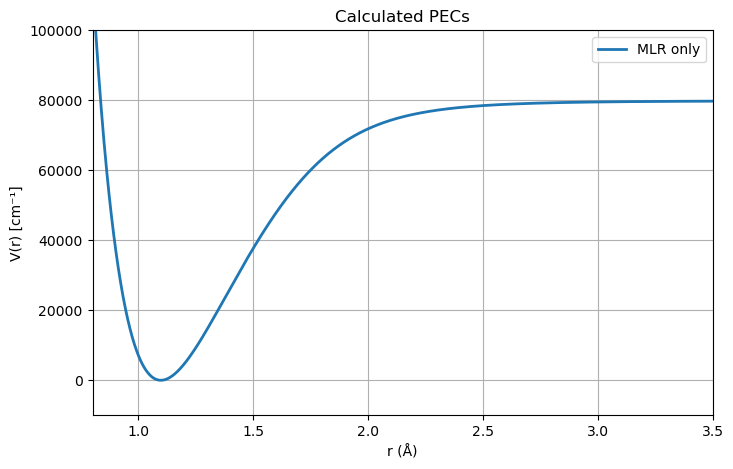

In [5]:
# plot calculated PEC only
plt.figure(figsize=(8,5))
plt.plot(rgrid, V_mlr, label="MLR only", lw=2)
plt.title("Calculated PECs")
plt.xlabel("r (Å)")
plt.ylabel("V(r) [cm⁻¹]")
plt.xlim(0.8, 3.5)
plt.ylim(-1e4, 1e5)

plt.grid(True)
plt.legend()
plt.show()


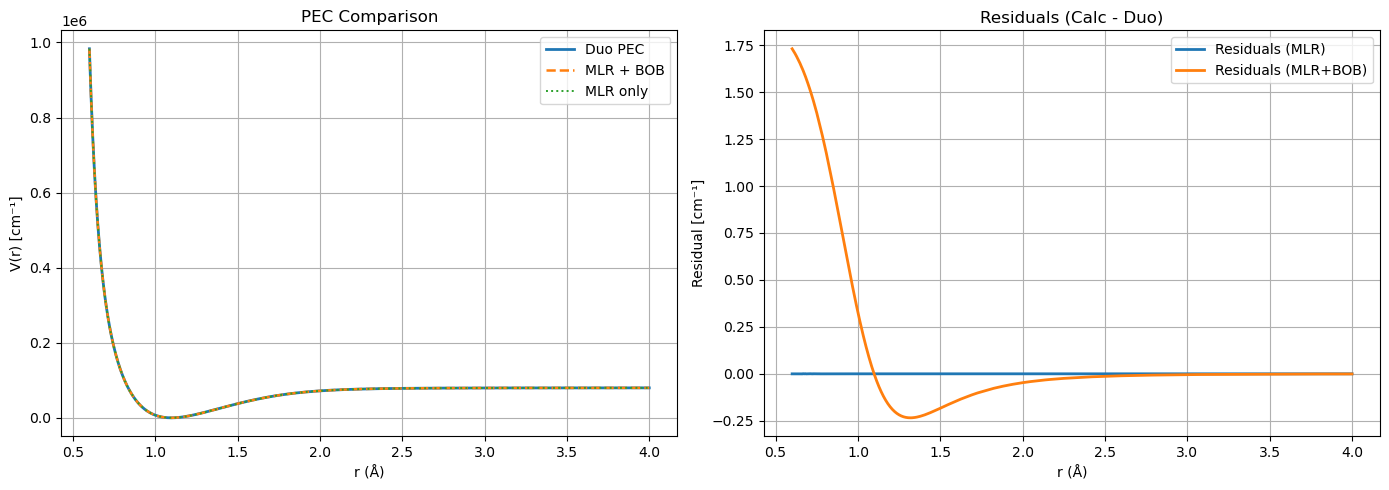

In [6]:
# plot_compare_with_duo(data, rmin=0.8, rmax=1.5)
plot_compare_with_duo(data)


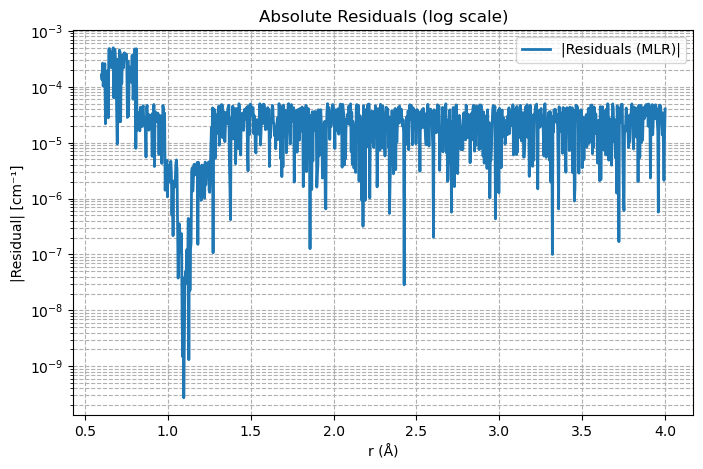

In [7]:

# make log plot of abs of residuals
plt.figure(figsize=(8,5))
plt.plot(data["r"], np.abs(data["res_mlr"]), label="|Residuals (MLR)|", lw=2)
# plt.plot(data["r"], np.abs(data["res_corr"]), label="|Residuals (MLR+BOB)|", lw=2)
plt.yscale("log")
plt.title("Absolute Residuals (log scale)")
plt.xlabel("r (Å)")
plt.ylabel("|Residual| [cm⁻¹]")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

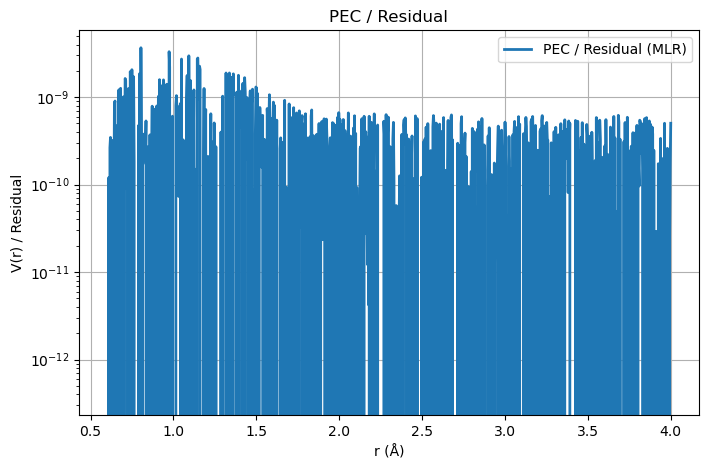

In [8]:
# calculate PEC divided by residual
plt.figure(figsize=(8,5))
plt.plot(data["r"], 1/ (V_duo / data["res_mlr"]), label="PEC / Residual (MLR)", lw=2)
plt.title("PEC / Residual")
# log plot
plt.yscale("log")
plt.xlabel("r (Å)")
plt.ylabel("V(r) / Residual")
plt.grid(True)
plt.legend()
plt.show()

### Plots for paper

#### Le Roy PEC plot

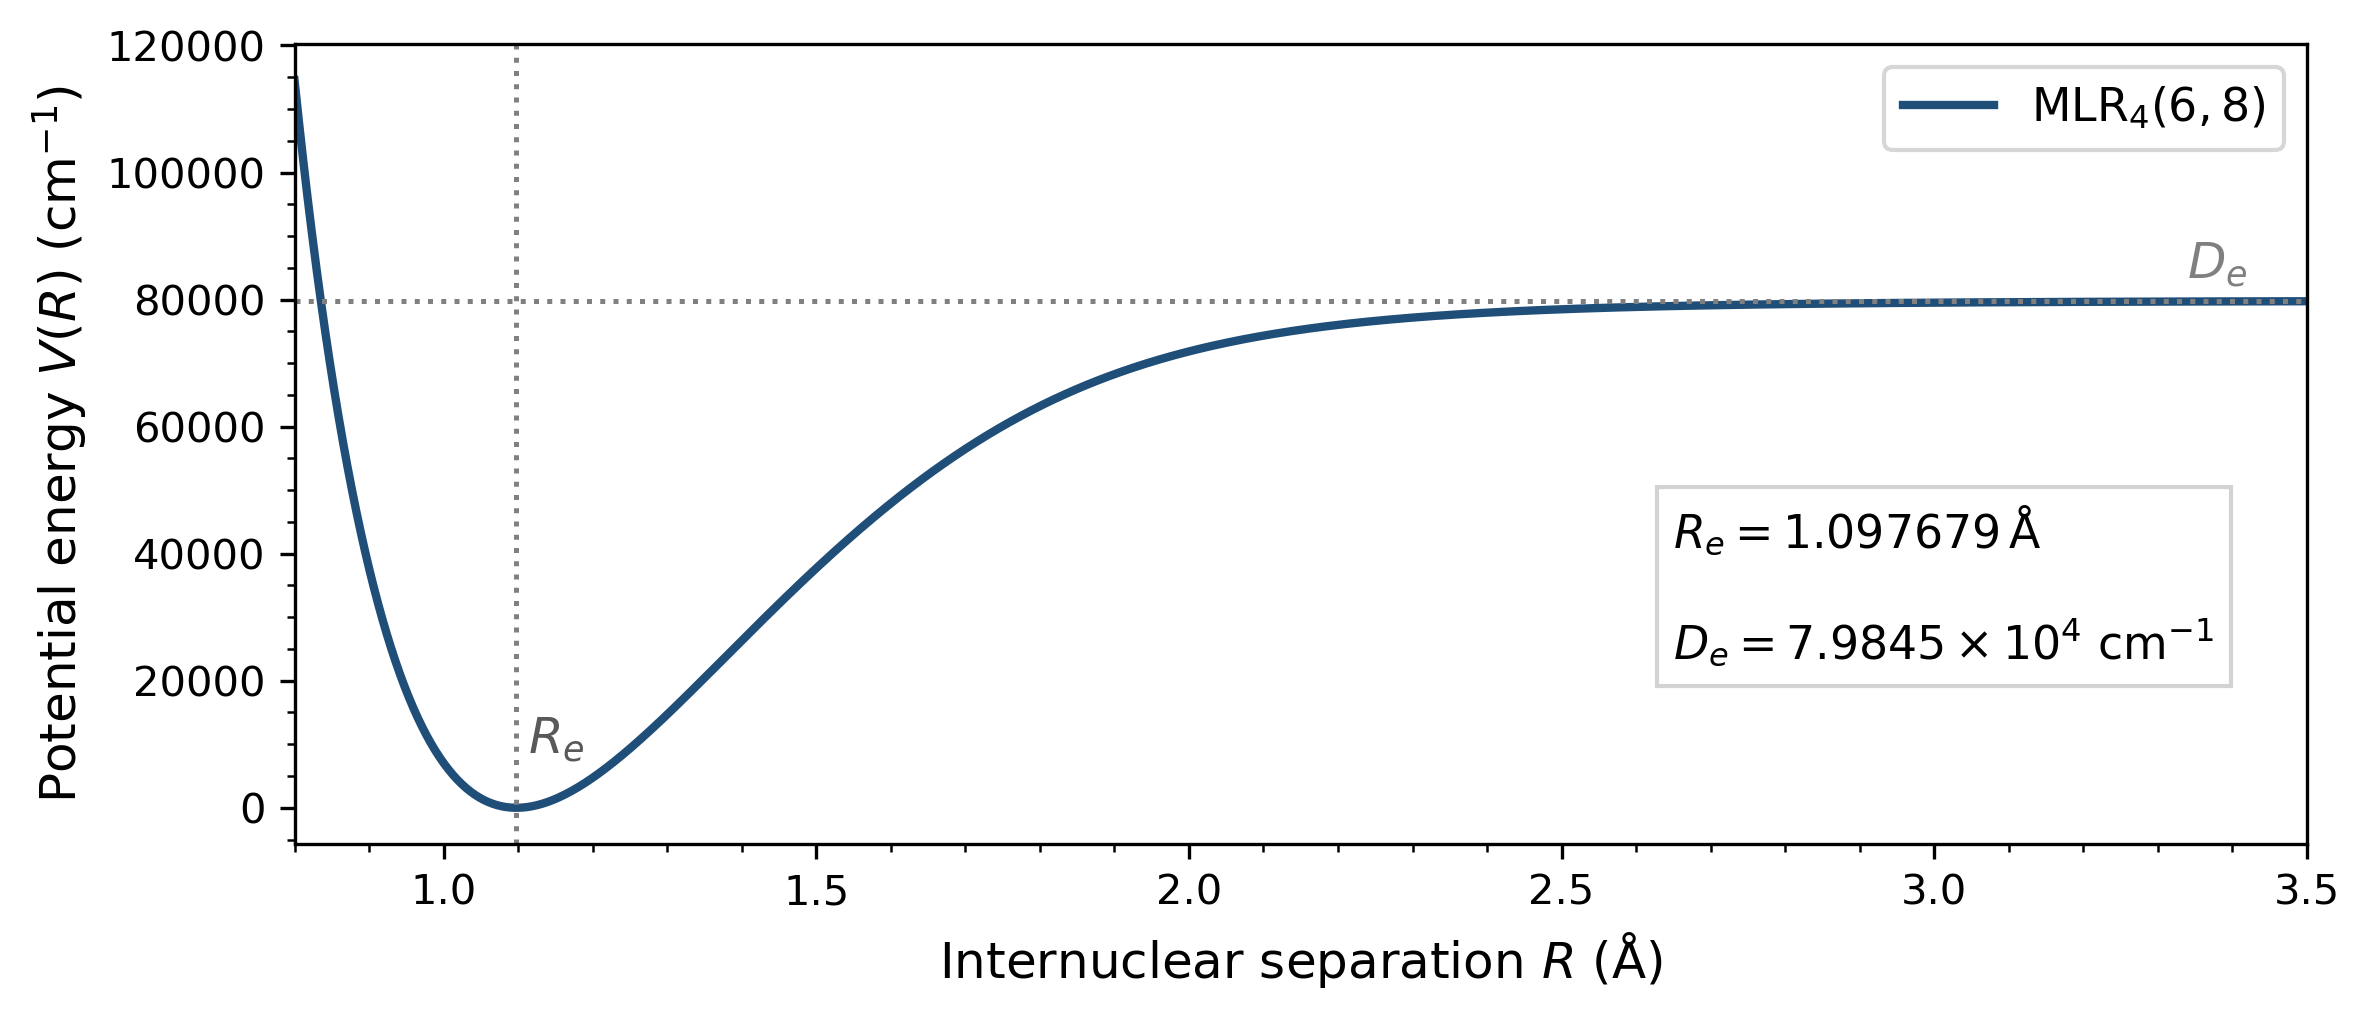

In [9]:
rgrid_paper = np.linspace(0.8, 3.75, 1000)
V_mlr_paper = V_MLR(rgrid_paper)

Re = 0.10976790E+01   # Å
De = 0.79845000000000E+05  # cm^-1

fig, ax = plt.subplots(figsize=(8, 3.5), dpi=300)

ax.plot(
    rgrid_paper,
    V_mlr_paper,
    lw=2,
    color="#1f4e79",
    label="MLR$_4(6,8)$"
)

# Mark equilibrium distance
ax.axvline(Re, ls=":", color="0.5", lw=1.2)
ax.text(
    Re + 0.015,
    ax.get_ylim()[0] + 0.1 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
    r"$R_e$",
    color="0.35",
    fontsize=12,
    ha="left",
    va="bottom",
)

# Mark dissociation energy
ax.axhline(De, ls=":", color="0.5", lw=1.2)
ax.text(
    3.42,
    De + 0.015 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
    r"$D_e$",
    color="grey",
    fontsize=12,
    ha="right",
    va="bottom"
)

param_text = (
    r"$R_e = 1.097679\,\mathrm{\AA}$" + "\n\n" +
    r"$D_e = 7.9845 \times 10^4\ \mathrm{cm^{-1}}$"
)

ax.text(
    2.65, De * 0.6,
    param_text,
    fontsize=11,
    ha="left", va="top",
    bbox=dict(facecolor="white", edgecolor="lightgrey", pad=4)
)

ax.set_xlabel(r"Internuclear separation $R$ ($\mathrm{\AA}$)", fontsize=12)
ax.set_ylabel(r"Potential energy $V(R)$ ($\mathrm{cm^{-1}}$)", fontsize=12)

ax.set_xlim(0.8, 3.5)
ax.minorticks_on()
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


#### BOB correction plot

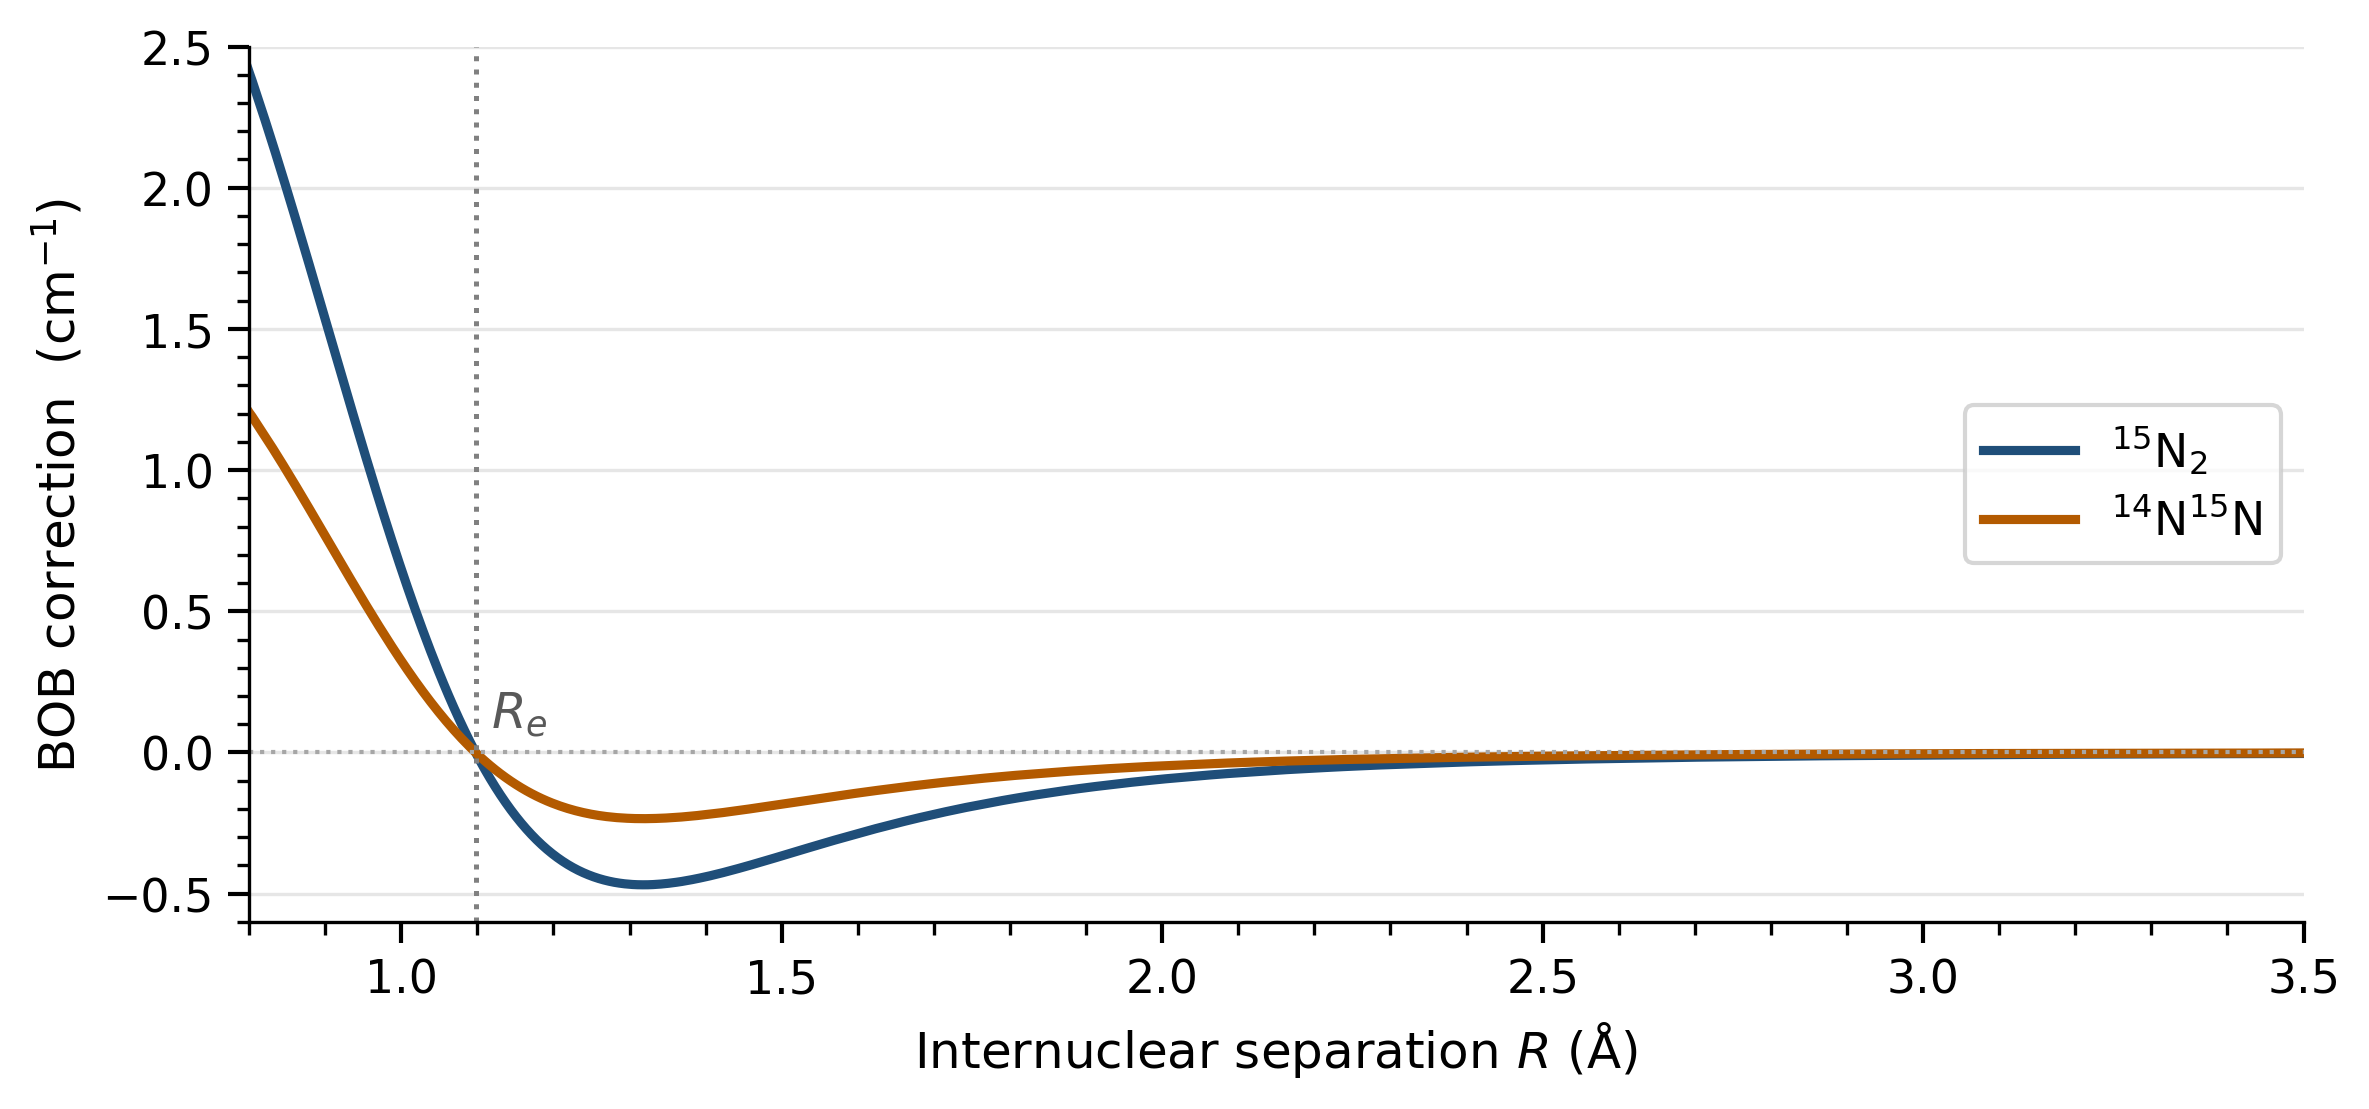

In [10]:
from matplotlib.ticker import AutoMinorLocator

N14N15_residual = np.load("BOB_correction_data/14N15N_BOB_correction.npy")
N152_residual   = np.load("BOB_correction_data/15N2_BOB_correction.npy")

fig, ax = plt.subplots(figsize=(8, 3.8), dpi=300)

# Curves
ax.plot(r_duo, N152_residual, lw=2.2, color="#1f4e79", label=r"$^{15}$N$_2$")
ax.plot(r_duo, N14N15_residual,   lw=2.2, color="#b35a00", label=r"$^{14}$N$^{15}$N")

# Reference line at zero
ax.axhline(0.0, color="0.65", lw=1.0, ls=":")

# Limits
ax.set_xlim(0.8, 3.5)
ax.set_ylim(-2.5, 0.6)
ax.set_ylim(-0.6, 2.5)

# Labels
ax.set_xlabel(r"Internuclear separation $R$ ($\mathrm{\AA}$)", fontsize=12)
ax.set_ylabel(r"BOB correction  ($\mathrm{cm^{-1}}$)", fontsize=12)

# Ticks
ax.tick_params(axis="both", which="major", labelsize=11, direction="out", length=5, width=1)
ax.tick_params(axis="both", which="minor", direction="out", length=3, width=0.8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# Grid: very light y-grid only
ax.grid(axis="y", color="0.9", lw=0.8)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(frameon=True, fontsize=11, loc="center right")


# draw vertical line at r_e
ax.axvline(Re, ls=":", color="0.5", lw=1.2)
ax.text(
    Re + 0.02,
    ax.get_ylim()[0] + 0.21 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
    r"$R_e$",
    color="0.35",
    fontsize=12,
    ha="left",
    va="bottom",
)


plt.tight_layout()
plt.show()

\caption{Residuals of the adiabatic correction to the $^{14}\mathrm{N}_2$ potential energy curve for $^{14}\mathrm{N}^{15}\mathrm{N}$ and $^{15}\mathrm{N}_2$ as a function of internuclear separation $R$.}